# 🛋️ Wayfair Customer Analytics: RFM Segmentation & CRM Optimization
**Role:** Customer Analytics Lead  
**Analysis Cutoff Date:** January 1, 2026  
**Architecture:** Hybrid Approach (Modular Production Engine in `src/` + Executive Presentation Notebook)

---

## 📌 Executive Summary & Business Scenario
Wayfair's CRM team has historically executed batch-and-blast email marketing campaigns, delivering identical promotions across the entire customer base. This one-size-fits-all approach has resulted in diminishing customer engagement, declining email click-through rates, and missed revenue opportunities.

To optimize the upcoming annual marketing calendar, this project segments customers based on their **actual transaction behavior** using **Recency, Frequency, and Monetary (RFM)** modeling as of **January 1, 2026**.

### Project Deliverables & Objectives:
1. **Data Ingestion & Hygiene:** Deduplicate transactions, resolve missing catalog pricing, and standardize data types.
2. **Qualifying Transaction Filtering:** Formulate and justify an economic threshold for valid customer value.
3. **RFM Metrics & Quintile Scoring:** Overcome tie-breaking limitations in frequency using rank-based quintile distributions.
4. **Behavioral Segmentation:** Group customers into 7 actionable cohorts (Champions, Loyal Customers, Potential Loyalists, New Customers, At Risk, Needs Attention, Lost).
5. **Attribution & Cohort Dynamics:** Validate channel effectiveness via Chi-Square testing and evaluate signup vintage performance.
6. **CRM Action Framework:** Deliver personalized activation playbooks and KPI measurement scorecards for each segment.


## 1. Environment & Modular Pipeline Setup
Following modern production standards, all core business logic is encapsulated in modular Python scripts located in `src/`:
- `src.config`: Centralized parameters, file paths, and CRM definitions
- `src.data_loader`: Data ingestion, catalog price imputation, and hygiene
- `src.rfm_engine`: Qualifying order logic, RFM calculations, and segment scoring
- `src.analysis`: Segment KPI aggregation, cohort analysis, and statistical hypothesis testing
- `src.visualization`: Production-grade visualization functions


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import modular components from src
from src.config import REFERENCE_DATE, OUTPUTS_DIR
from src.data_loader import load_raw_data, clean_datasets, get_cleaning_summary
from src.rfm_engine import (
    filter_qualifying_orders,
    calculate_rfm_metrics,
    score_rfm_quintiles,
    segment_customers
)
from src.analysis import (
    compute_segment_kpis,
    analyze_channel_attribution,
    analyze_signup_cohorts,
    build_crm_strategy_dataframe
)
from src.visualization import (
    plot_segment_distribution,
    plot_revenue_share,
    plot_rfm_heatmap,
    plot_recency_vs_frequency,
    plot_segment_by_channel,
    plot_segment_by_cohort
)

# Plot display settings for Jupyter
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(f"System initialized. Reference snapshot date: {REFERENCE_DATE.strftime('%Y-%m-%d')}")


System initialized. Reference snapshot date: 2026-01-01


## 2. Data Ingestion & Data Hygiene
Raw transactional datasets frequently suffer from data anomalies including duplicate checkouts, missing unit prices, and inconsistent string casing. 

We ingest the four core datasets and apply deterministic cleaning:
1. **Deduplication:** Remove repeated `order_id` records in `orders.csv`.
2. **Missing Price Imputation:** 199 unit prices in `order_items.csv` are missing. Rather than using an arbitrary mean, we accurately impute the catalog `list_price` from `products.csv`.
3. **Categorical Normalization:** Normalize inconsistent product category casings (`Kitchen`, `kitchen`, `KITCHEN` -> `Kitchen`).
4. **Whitespace & Date Parsing:** Strip whitespace and convert timestamp columns.


In [2]:
# Ingest raw files
orders_raw, items_raw, products_raw, customers_raw = load_raw_data()

# Execute cleaning
orders, items, products, customers = clean_datasets(
    orders_raw, items_raw, products_raw, customers_raw
)

# Audit cleaning metrics
audit = get_cleaning_summary(orders_raw, orders, items_raw, items, products, customers)
pd.DataFrame([audit]).T.rename(columns={0: 'Metric Value'})


,Metric Value
raw_orders_count,9245
clean_orders_count,9207
duplicate_orders_removed,38
raw_items_count,15608
clean_items_count,15608
missing_prices_imputed,199
products_count,90
unique_categories,8
total_registered_customers,3600
date_range_start,2024-01-01 09:24:45


## 3. Defining Qualifying Orders
### Economic Justification for Order Eligibility:
To determine a customer's true economic value, we must establish rigorous criteria for which orders count toward RFM:
- **Canceled Orders (`344` orders):** These transactions were aborted before fulfillment or payment completion. They generated zero gross or net revenue.
- **Returned Orders (`407` orders):** These products were returned and refunded. Counting them would artificially inflate customer monetary value and frequency.
- **Completed Orders (`8,456` orders):** These represent fulfilled purchases reflecting verified customer demand and net economic contribution.

**Net Order Spend Formulation:**
$$\text{Line Net Revenue} = (\text{quantity} \times \text{unit\_price}) - \text{discount\_amount}$$
$$\text{Order Total} = \sum \text{Line Net Revenue} + \text{shipping\_fee}$$


In [3]:
# Filter qualifying completed transactions
qualifying_orders = filter_qualifying_orders(orders, items)

print(f"Total raw orders:        {len(orders):,}")
print(f"Qualifying orders:       {len(qualifying_orders):,} ({(len(qualifying_orders)/len(orders)):.1%} qualification rate)")
print(f"Total realized spend:    ${qualifying_orders['order_total'].sum():,.2f}")
qualifying_orders.head()


Total raw orders:        9,207
Qualifying orders:       8,456 (91.8% qualification rate)
Total realized spend:    $1,894,410.58


,order_id,customer_id,order_date,shipping_fee,line_net_revenue,order_total
0,100001,1530,2024-01-01 09:24:45,6.95,38.99,45.94
1,100002,3531,2024-01-01 10:37:49,0.00,187.98,187.98
2,100003,840,2024-01-01 10:59:09,0.00,139.99,139.99
3,100004,725,2024-01-01 12:48:34,0.00,188.97,188.97
4,100005,3452,2024-01-01 17:44:03,0.00,124.99,124.99


## 4. RFM Metrics Calculation (Snapshot: Jan 1, 2026)
For every customer with at least one completed purchase, we compute:
- **Recency ($R$):** Days elapsed from the customer's last qualifying order date to the analysis cutoff ($2026\text{-}01\text{-}01$).
- **Frequency ($F$):** Total count of unique completed orders placed.
- **Monetary ($M$):** Cumulative dollar spend across all qualifying orders.


In [4]:
rfm_base = calculate_rfm_metrics(qualifying_orders, ref_date=REFERENCE_DATE)
print(f"Total customers evaluated: {len(rfm_base):,} (out of {len(customers):,} total accounts)")
rfm_base[['recency', 'frequency', 'monetary']].describe()


Total customers evaluated: 2,047 (out of 3,600 total accounts)


,recency,frequency,monetary
count,2047.00,2047.00,2047.00
mean,195.25,4.13,925.46
std,183.42,6.19,1458.66
min,0.00,1.00,13.34
25%,36.00,1.00,182.68
50%,135.00,2.00,491.57
75%,314.50,4.00,1098.76
max,722.00,75.00,18835.88


## 5. Quintile Scoring & Tie-Breaking
Standard quantile binning (`pd.qcut`) often fails when data contains repeated values (ties), which is exceptionally common in purchase frequency where many customers order exactly 1 or 2 times.

### Solution:
We break ties deterministically using `rank(method='first')` prior to quintile binning.
- **Recency:** Inverted scale ($1$ to $5$), where $5$ represents the most recent buyers (lowest days).
- **Frequency:** Standard scale ($1$ to $5$), where $5$ represents high-frequency purchasers.
- **Monetary:** Standard scale ($1$ to $5$), where $5$ represents top spenders.


In [5]:
scored_rfm = score_rfm_quintiles(rfm_base)

# Verify uniform distribution across quintiles (each ~409-410 customers)
score_dist = pd.DataFrame({
    'R_Score': scored_rfm['r_score'].value_counts(),
    'F_Score': scored_rfm['f_score'].value_counts(),
    'M_Score': scored_rfm['m_score'].value_counts()
}).sort_index()
score_dist


,R_Score,F_Score,M_Score
1,410,410,410
2,409,409,409
3,409,409,409
4,409,409,409
5,410,410,410


## 6. Customer Segmentation Rules
Customers are segmented into 7 distinct behavioral cohorts using deterministic multi-score rules:

| Segment | Scoring Logic | Description |
| :--- | :--- | :--- |
| **Champions** | $R \ge 4$ and $F \ge 4$ | Bought recently, buy frequently, and generate top revenue. |
| **Loyal Customers** | $(F \ge 4 \text{ and } R < 4)$ or $(F \ge 3 \text{ and } R \ge 3 \text{ and } M \ge 4)$ | Steady repeat buyers with strong historical engagement. |
| **Potential Loyalists** | $R \ge 4$ and $F \in \{2, 3\}$ | Recent buyers with multiple purchases; prime candidates for loyalty. |
| **New Customers** | $R \ge 4$ and $F = 1$ | First-time buyers acquired recently who require onboarding. |
| **At Risk** | $R \in \{2, 3\}$ and $F \ge 3$ | Former repeat buyers who have not purchased recently. |
| **Needs Attention** | $R \in \{2, 3\}$ and $F \in \{1, 2\}$ | Low frequency and drifting recency; slipping engagement. |
| **Lost** | $R = 1$ | Haven't purchased in a very long time; inactive accounts. |


In [6]:
segmented_rfm = segment_customers(scored_rfm)
segmented_rfm['segment'].value_counts().to_frame(name='Customer Count')


,Customer Count
segment,
Loyal Customers,536
Champions,351
Needs Attention,328
Potential Loyalists,283
Lost,267
At Risk,143
New Customers,139


## 7. Segment Financial & Behavioral Performance
We evaluate the revenue contribution, average order value (AOV), and purchase frequency across segments.


In [7]:
summary_table = compute_segment_kpis(segmented_rfm)
summary_table


,segment,num_customers,pct_total_customers,total_revenue,pct_total_revenue,avg_monetary,avg_order_value,avg_recency,avg_frequency,median_days_between_orders
0,Loyal Customers,536,26.18,891518.39,47.06,1663.28,237.93,265.56,6.99,40.50
1,Champions,351,17.15,668588.75,35.29,1904.81,219.57,30.78,8.68,41.00
2,Potential Loyalists,283,13.83,82556.28,4.36,291.72,177.92,36.40,1.64,46.50
3,Needs Attention,328,16.02,78259.74,4.13,238.60,215.59,206.29,1.11,66.00
4,Lost,267,13.04,75608.22,3.99,283.18,200.02,495.34,1.42,37.00
5,At Risk,143,6.99,71755.08,3.79,501.78,224.23,219.80,2.24,63.00
6,New Customers,139,6.79,26124.12,1.38,187.94,187.94,35.06,1.00,NaN


### 💡 Key Commercial Insight: The Pareto Concentration
- **Champions + Loyal Customers** represent **43.3%** of all active customers, yet drive **82.4%** of total store revenue ($1.56M of $1.89M).
- **Champions** demonstrate the shortest purchase cycle (average **41 days** between orders) and highest overall customer value ($1,904.81 average spend).
- **Lost Customers** have been absent for an average of **495 days**, making aggressive re-acquisition uneconomic compared to loyalty nurturing.


## 8. Portfolio Visualizations

### 8.1 Customer Count Distribution & Revenue Contribution


findfont: Failed to find font weight semibold for Arial, now using 700.


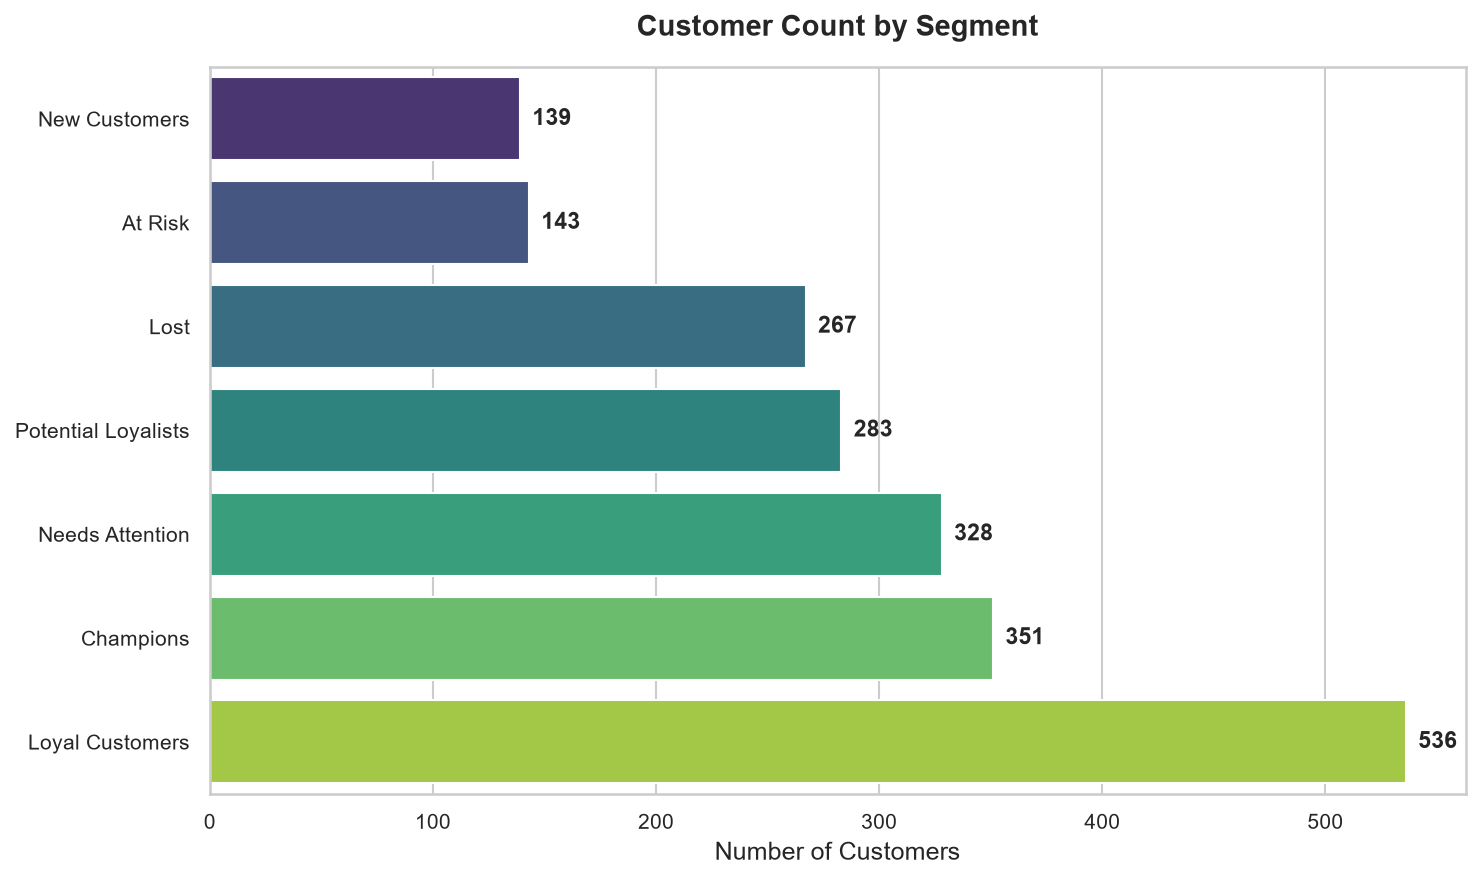

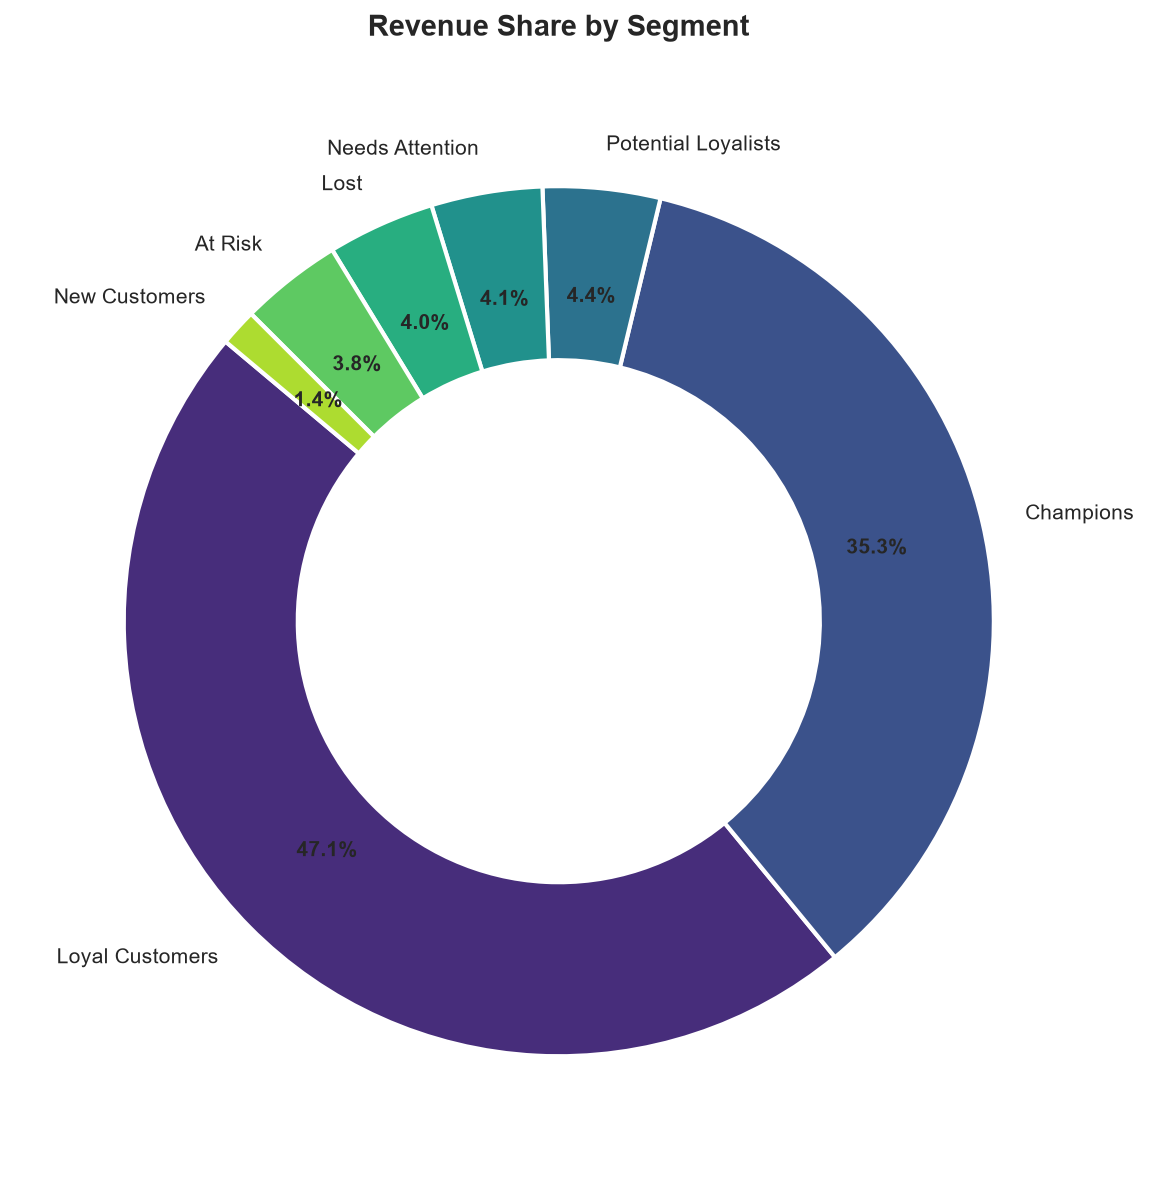

In [8]:
fig_dist = plot_segment_distribution(summary_table)
plt.show()

fig_rev = plot_revenue_share(summary_table)
plt.show()


### 8.2 RFM Monetary Heatmap & Behavioral Scatter
The heatmap illuminates the relationship between Recency and Frequency scores on average customer spend.


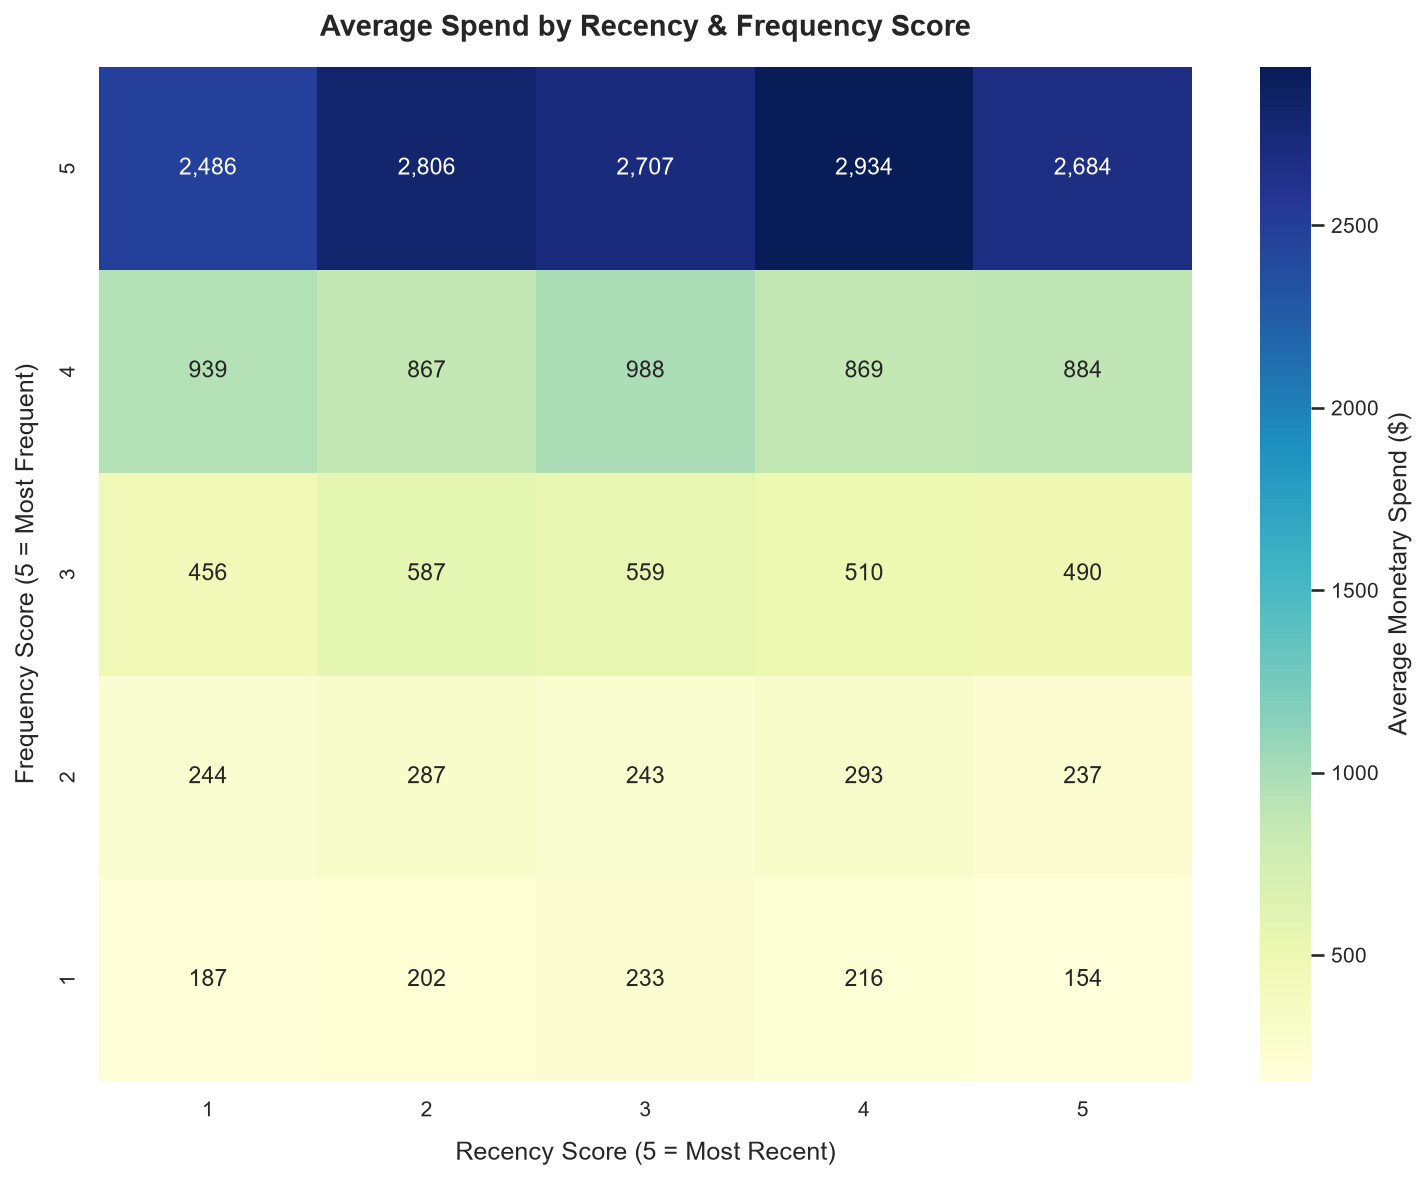

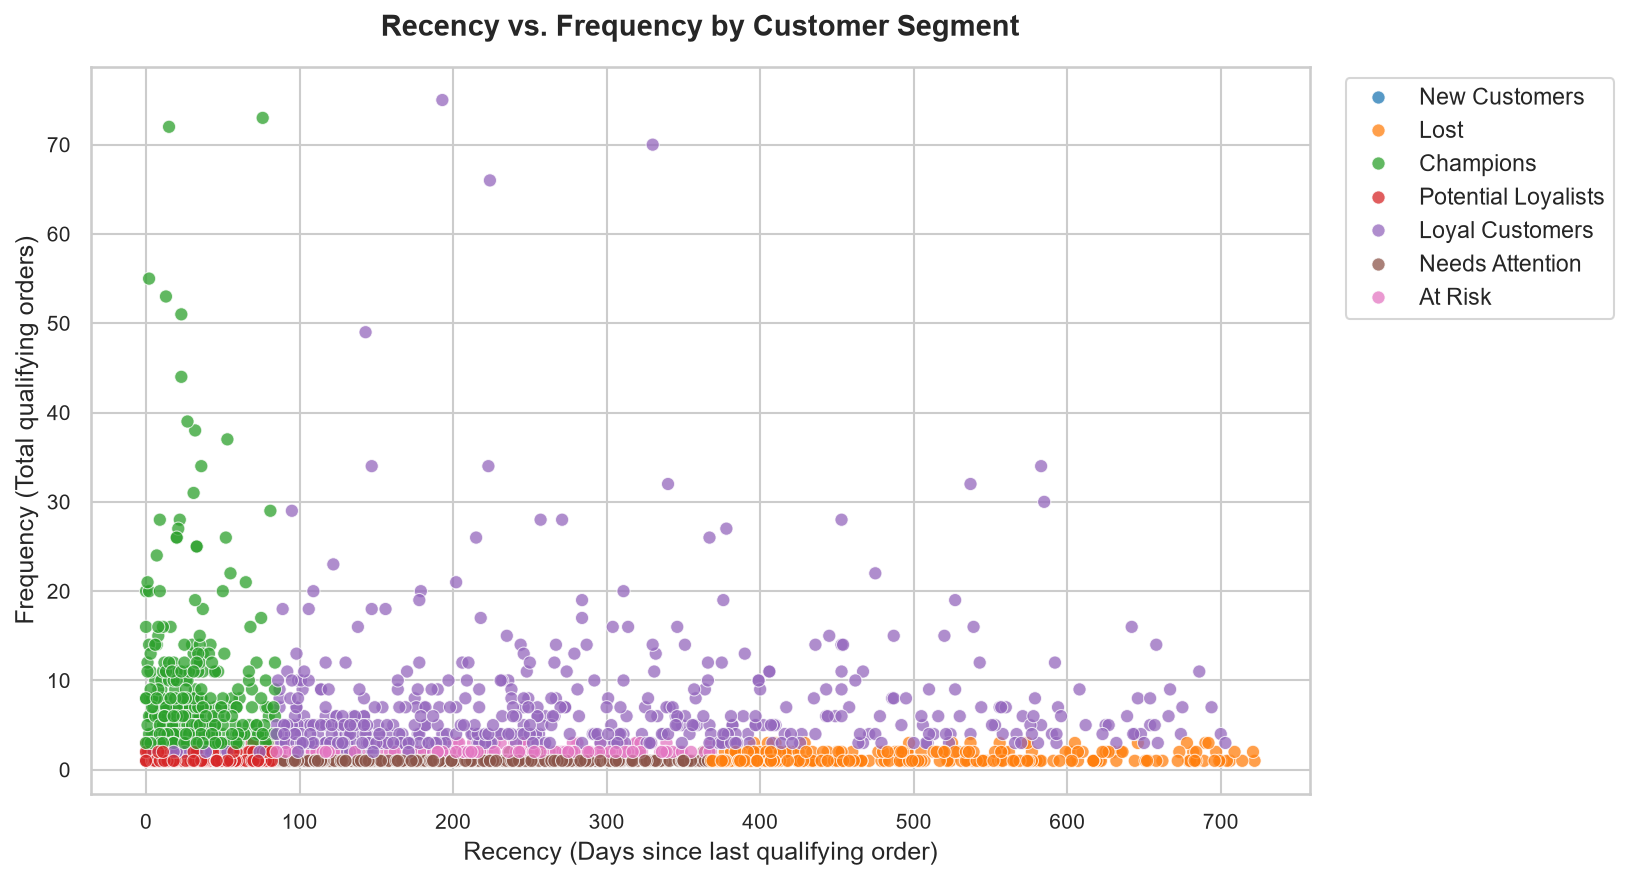

In [9]:
fig_heat = plot_rfm_heatmap(segmented_rfm)
plt.show()

fig_scatter = plot_recency_vs_frequency(segmented_rfm)
plt.show()


## 9. Attribution & Cohort Dynamics

### 9.1 Acquisition Channel Effectiveness (Chi-Square Test)
Does initial acquisition channel influence which segment a customer eventually becomes?


Chi-Square Test p-value: 2.2226e-06 -> Statistically Significant: True


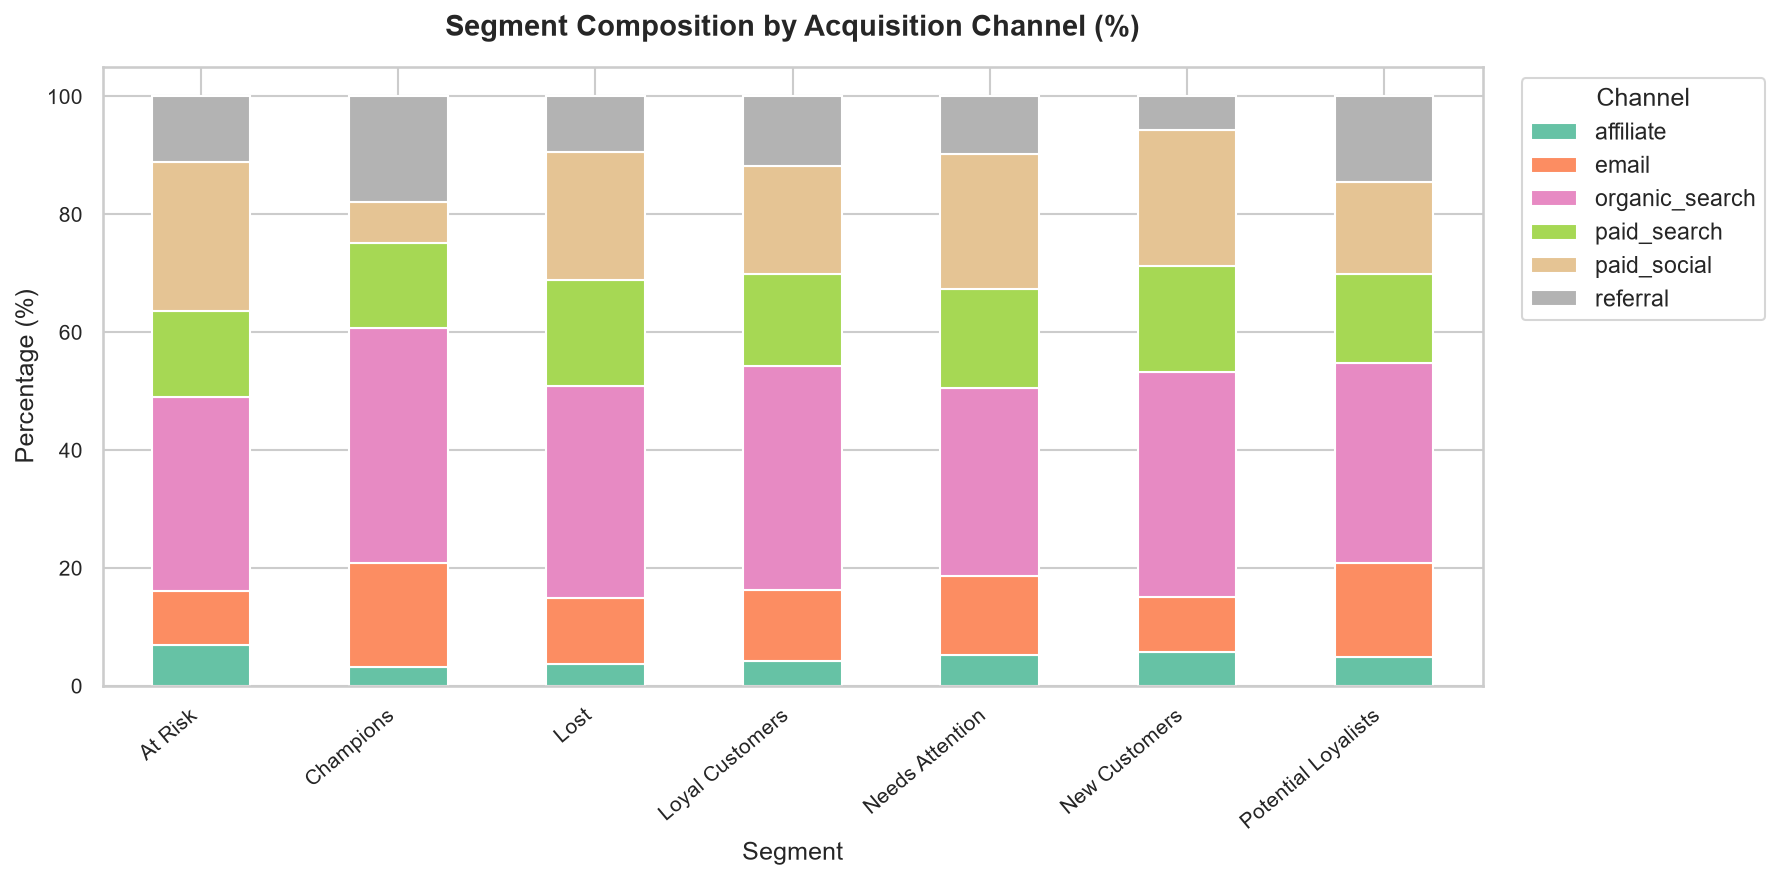

In [10]:
count_channel, pct_channel, p_val, is_sig = analyze_channel_attribution(segmented_rfm, customers)
print(f"Chi-Square Test p-value: {p_val:.4e} -> Statistically Significant: {is_sig}")

fig_channel = plot_segment_by_channel(pct_channel)
plt.show()


### 9.2 Signup Cohort Migration
Analyzing customer composition by account vintage (2023, 2024, 2025).


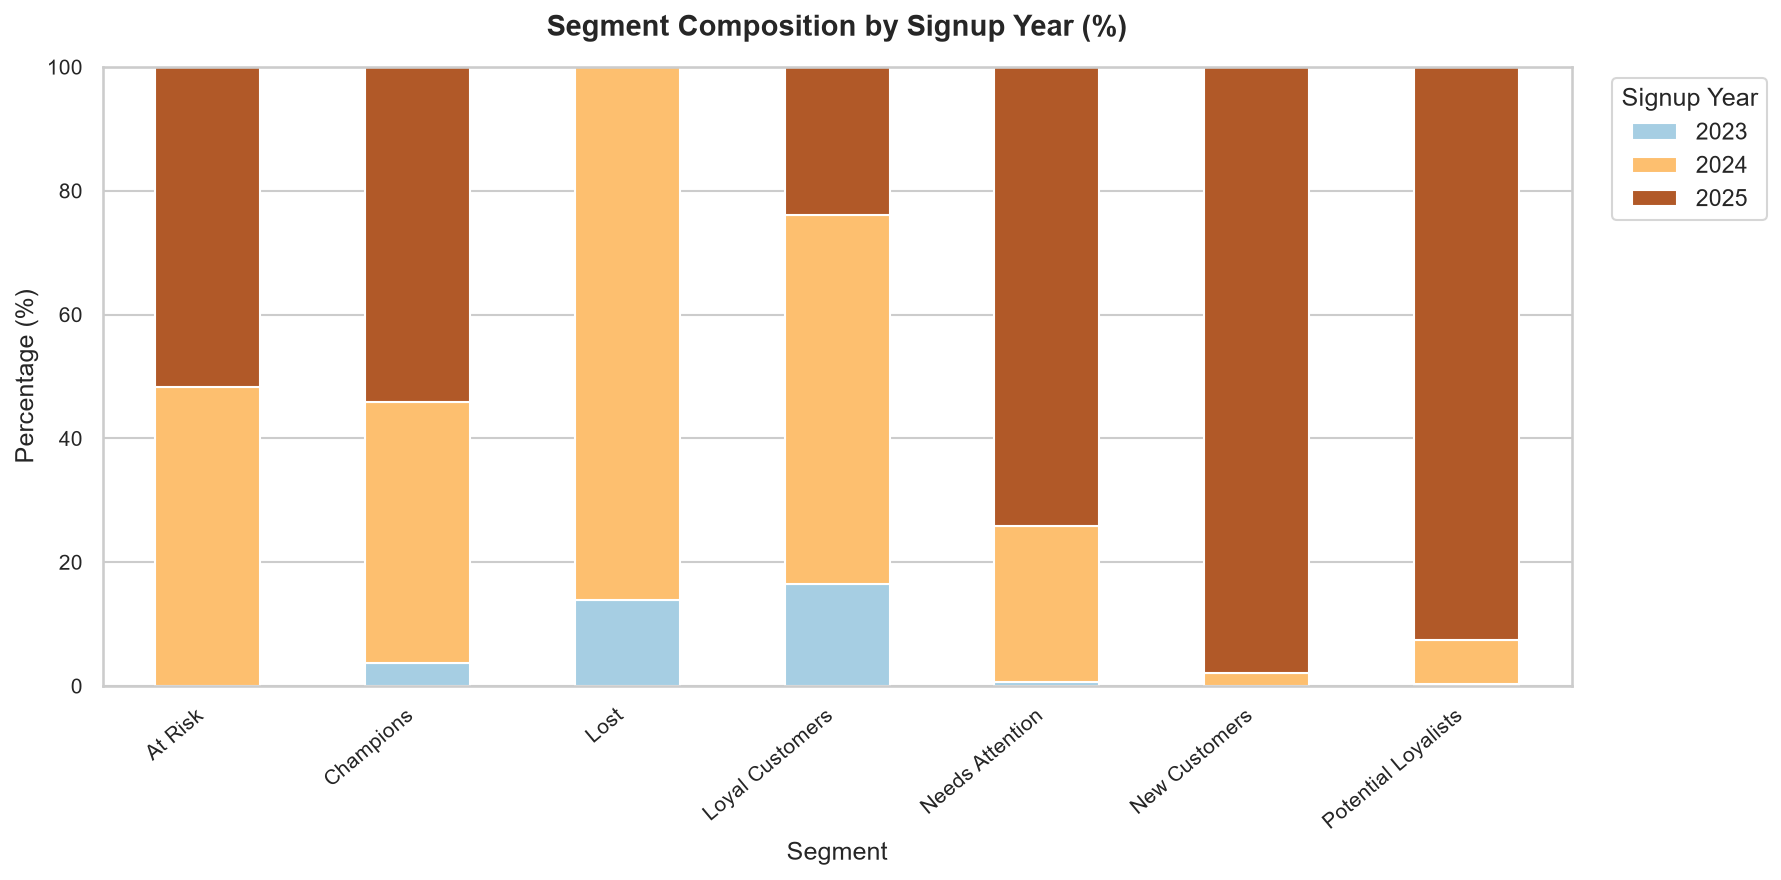

In [11]:
count_cohort, pct_cohort = analyze_signup_cohorts(segmented_rfm, customers)
fig_cohort = plot_segment_by_cohort(pct_cohort)
plt.show()


## 10. Strategic CRM Action Plan & KPI Matrix
The ultimate goal of customer segmentation is empowering the CRM marketing team with personalized treatments and clear metrics of success:


In [12]:
crm_df = build_crm_strategy_dataframe()
crm_df


,Segment,Strategic Priority,Recommended CRM Action,Primary Success Metric
0,Champions,High Retention,"VIP loyalty perks, early access to new lines, ...",Repeat purchase rate & average order value (AOV)
1,Loyal Customers,Value Maximization,"Loyalty tier rewards, personalized cross-selli...",Customer lifetime value (CLV) & cross-category...
2,Potential Loyalists,Nurturing,"Post-purchase engagement, category recommendat...",Conversion rate to 3rd qualifying purchase wit...
3,New Customers,Activation,"Welcome onboarding drip series, brand intro, f...",Second purchase rate within 30 days of initial...
4,At Risk,Win-Back,"Personalized re-activation campaign, feedback ...",Reactivation rate (orders placed within 45 days)
5,Needs Attention,Re-engagement,"Engagement check-in email series, price-drop a...","Email open rate, click-through rate, and site ..."
6,Lost,Sunset / Cleanse,Deep discount reactivation email; if unrespons...,"Reactivation rate (if < 2%, suppress to protec..."


## 11. Pipeline Exports & Reproducibility
The final deliverables (`customer_segments.csv` and `segment_summary.csv`) are written to the `outputs/` directory.


In [13]:
export_cols = [
    'customer_id', 'recency', 'frequency', 'monetary',
    'r_score', 'f_score', 'm_score', 'rfm_score', 'segment'
]
segmented_rfm[export_cols].to_csv(OUTPUTS_DIR / "customer_segments.csv", index=False)
summary_table.to_csv(OUTPUTS_DIR / "segment_summary.csv", index=False)
print("Deliverables successfully updated in outputs directory.")


Deliverables successfully updated in outputs directory.


---
## 🎯 Resume & Interview Talking Points
- **Architecture:** Implemented a hybrid data science architecture decoupling modular production pipelines (`src/`) from interactive analytical storytelling (`notebooks/`).
- **Data Engineering:** Ingested 9.2k orders, removed duplicate transactions, and imputed 199 missing product prices using catalog list-price matching.
- **RFM Modeling:** Applied rank-based tie-breaking for frequency quintile binning and classified 2,047 active customers across 7 distinct behavioral segments.
- **Business Impact:** Identified that 43.3% of customers (Champions & Loyalists) generate 82.4% of total revenue ($1.56M), delivering tailored CRM playbooks with quantifiable KPIs to reduce churn and maximize CLV.
